# UAS Sightings Exploratory Data Analysis (EDA) with PySpark
**Author(s):** 
* Brett Allen
* Dev Parikh
* Lokesh Reddy Venna

**Environment:**
```
   SageMaker Image: SparkAnalytics 3.0
  SageMaker Kernel: Glue PySpark
SageMaker Instance: ml.t3.medium (2 vCPU + 4 GiB @ $0.0416/hr) - EBS storage only (for HDFS)
```

**NOTE:** Must have the specified `%profile` available on system. Install AWS CLI via `pip install awscli` and run `aws configure` to initialize CLI environment. Must have generated keys in IAM first.

**NOTE:** Additional jars are required for `apache-sedona`. Refer to https://sedona.apache.org/1.3.1-incubating/setup/install-python/

**NOTE:** Need to download the following jars and upload to s3 for reference via `%extra_jars` magic:
* `geotools-wrapper-1.1.0-25.2.jar`: https://mvnrepository.com/artifact/org.datasyslab/geotools-wrapper/1.1.0-25.2
* `gt-epsg-hsql-24.0.jar`: https://mvnrepository.com/artifact/org.geotools/gt-epsg-hsql/24.0
* `gt-main-24.0.jar`: https://mvnrepository.com/artifact/org.geotools/gt-main/24.0
* `gt-referencing-24.0.jar`: https://mvnrepository.com/artifact/org.geotools/gt-referencing/24.0
* `jts-core-1.18.2.jar`: https://mvnrepository.com/artifact/org.locationtech.jts/jts-core/1.18.2
* `jts-io-common-1.18.2.jar`: https://mvnrepository.com/artifact/org.locationtech.jts.io/jts-io-common/1.18.2
* `sedona-core-3.0_2.12-1.1.0-incubating.jar`: https://mvnrepository.com/artifact/org.apache.sedona/sedona-core-3.0_2.12/1.1.0-incubating
* `sedona-python-adapter-3.0_2.12-1.1.0-incubating.jar`: https://mvnrepository.com/artifact/org.apache.sedona/sedona-python-adapter-3.0_2.12/1.1.0-incubating
* `sedona-sql-3.0_2.12-1.1.0-incubating.jar`: https://mvnrepository.com/artifact/org.apache.sedona/sedona-sql-3.0_2.12/1.1.0-incubating
* `sedona-viz-3.0_2.12-1.1.0-incubating.jar`: https://mvnrepository.com/artifact/org.apache.sedona/sedona-viz-3.0_2.12/1.1.0-incubating


In [53]:
%iam_role arn:aws:iam::867344433302:role/endurasoft-GlueJobServiceRole
%profile default
%etl
%number_of_workers 2
%worker_type G.2X
%glue_version 3.0
%additional_python_modules "plotly-express,datashader,apache-sedona,geopandas,shapely,geojson,dask[dataframe],folium"
%extra_jars "s3://endurasoft-dev-risk-framework/config/jars/apache_sedona_glue_v3/geotools-wrapper-1.1.0-25.2.jar,s3://endurasoft-dev-risk-framework/config/jars/apache_sedona_glue_v3/gt-epsg-hsql-24.0.jar,s3://endurasoft-dev-risk-framework/config/jars/apache_sedona_glue_v3/gt-main-24.0.jar,s3://endurasoft-dev-risk-framework/config/jars/apache_sedona_glue_v3/gt-referencing-24.0.jar,s3://endurasoft-dev-risk-framework/config/jars/apache_sedona_glue_v3/jts-core-1.18.2.jar,s3://endurasoft-dev-risk-framework/config/jars/apache_sedona_glue_v3/jts-io-common-1.18.2.jar,s3://endurasoft-dev-risk-framework/config/jars/apache_sedona_glue_v3/sedona-core-3.0_2.12-1.1.0-incubating.jar,s3://endurasoft-dev-risk-framework/config/jars/apache_sedona_glue_v3/sedona-python-adapter-3.0_2.12-1.1.0-incubating.jar,s3://endurasoft-dev-risk-framework/config/jars/apache_sedona_glue_v3/sedona-sql-3.0_2.12-1.1.0-incubating.jar,s3://endurasoft-dev-risk-framework/config/jars/apache_sedona_glue_v3/sedona-viz-3.0_2.12-1.1.0-incubating.jar"

Current iam_role is arn:aws:iam::867344433302:role/endurasoft-GlueJobServiceRole
iam_role has been set to arn:aws:iam::867344433302:role/endurasoft-GlueJobServiceRole.
Previous profile: default
Setting new profile to: default
Previous session type: etl
Setting new session type to ETL
Previous number of workers: 2
Setting new number of workers to: 2
Previous worker type: G.2X
Setting new worker type to: G.2X
Setting Glue version to: 3.0
Additional python modules to be included:
plotly-express
datashader
apache-sedona
geopandas
shapely
geojson
dask[dataframe]
folium
Extra jars to be included:
s3://endurasoft-dev-risk-framework/config/jars/apache_sedona_glue_v3/geotools-wrapper-1.1.0-25.2.jar
s3://endurasoft-dev-risk-framework/config/jars/apache_sedona_glue_v3/gt-epsg-hsql-24.0.jar
s3://endurasoft-dev-risk-framework/config/jars/apache_sedona_glue_v3/gt-main-24.0.jar
s3://endurasoft-dev-risk-framework/config/jars/apache_sedona_glue_v3/gt-referencing-24.0.jar
s3://endurasoft-dev-risk-framew

## Imports

In [1]:
from awsglue.transforms import *
from awsglue.utils import getResolvedOptions
from awsglue.context import GlueContext
from awsglue.job import Job
from pyspark.sql import SparkSession, DataFrame
from pyspark.sql.window import Window
from pyspark import StorageLevel
from pyspark.context import SparkContext
from pyspark.conf import SparkConf
import pyspark.sql.types as T
import pyspark.sql.functions as F
from pyspark.sql import Row
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.clustering import KMeans
from pyspark.ml.feature import VectorAssembler, StringIndexer
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.stat import Correlation
from pyspark.mllib.linalg.distributed import RowMatrix
from sedona.register import SedonaRegistrator
from sedona.core.formatMapper.shapefileParser import ShapefileReader
from sedona.core.formatMapper import GeoJsonReader
from sedona.core.enums import FileDataSplitter
from sedona.core import SpatialRDD
from sedona.utils import SedonaKryoRegistrator, KryoSerializer
import pandas as pd
import geopandas as gpd
import shapely
from shapely.geometry import shape, Point, Polygon
import re
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
import plotly.express as px
from colorcet import fire
import datashader.transfer_functions as tf
import datashader as ds
import boto3
import io
import json
import geojson

Trying to create a Glue session for the kernel.
Session Type: etl
Worker Type: G.2X
Number of Workers: 2
Session ID: b0b343e7-c02e-4450-8f23-2f023e63536f
Applying the following default arguments:
--glue_kernel_version 1.0.7
--enable-glue-datacatalog true
--extra-jars s3://endurasoft-dev-risk-framework/config/jars/apache_sedona_glue_v3/geotools-wrapper-1.1.0-25.2.jar,s3://endurasoft-dev-risk-framework/config/jars/apache_sedona_glue_v3/gt-epsg-hsql-24.0.jar,s3://endurasoft-dev-risk-framework/config/jars/apache_sedona_glue_v3/gt-main-24.0.jar,s3://endurasoft-dev-risk-framework/config/jars/apache_sedona_glue_v3/gt-referencing-24.0.jar,s3://endurasoft-dev-risk-framework/config/jars/apache_sedona_glue_v3/jts-core-1.18.2.jar,s3://endurasoft-dev-risk-framework/config/jars/apache_sedona_glue_v3/jts-io-common-1.18.2.jar,s3://endurasoft-dev-risk-framework/config/jars/apache_sedona_glue_v3/sedona-core-3.0_2.12-1.1.0-incubating.jar,s3://endurasoft-dev-risk-framework/config/jars/apache_sedona_glue_v

In [55]:
%status

Session ID: b0b343e7-c02e-4450-8f23-2f023e63536f
Status: READY
Role: arn:aws:iam::867344433302:role/endurasoft-GlueJobServiceRole
CreatedOn: 2024-12-01 22:30:06.743000+00:00
GlueVersion: 3.0
Session Type: glueetl
Idle Timeout: 2880
Timeout: 2880
Tags: {'owner': 'AIDA4T4OBYCLOCNMZTZU3', 'sagemaker:user-profile-arn': 'arn:aws:sagemaker:us-east-1:867344433302:user-profile/d-eikyi6u8iy8g/ballen', 'sagemaker:domain-arn': 'arn:aws:sagemaker:us-east-1:867344433302:domain/d-eikyi6u8iy8g', 'sagemaker:space-arn': 'arn:aws:sagemaker:us-east-1:867344433302:space/d-eikyi6u8iy8g/Bretts-Private-JupyterLab-Space'}
Worker Type: G.2X
Number of Workers: 2
Region: us-east-1
Applying the following default arguments:
--glue_kernel_version 1.0.7
--enable-glue-datacatalog true
--extra-jars s3://endurasoft-dev-risk-framework/config/jars/apache_sedona_glue_v3/geotools-wrapper-1.1.0-25.2.jar,s3://endurasoft-dev-risk-framework/config/jars/apache_sedona_glue_v3/gt-epsg-hsql-24.0.jar,s3://endurasoft-dev-risk-framew

## Configurations
For reference/guidance on using sedona for geospatial analysis, see https://anant-sharma.medium.com/apache-sedona-geospark-using-pyspark-e60485318fbe

In [2]:
# Initialize spark context and glue context to create glue job for analysis
conf = SparkConf()
conf.set("spark.serializer", KryoSerializer.getName)\
    .set("spark.kryo.registrator", SedonaKryoRegistrator.getName)
sc = SparkContext.getOrCreate(conf=conf)
glueContext = GlueContext(sc)
spark = glueContext.spark_session
job = Job(glueContext)

In [3]:
# Register spark with sedona
SedonaRegistrator.registerAll(spark)

True


In [4]:
spark.conf.set("spark.sql.files.ignoreCorruptFiles", "true")
spark.conf.set("spark.sql.parquet.enableVectorizedReader", "false")

In [5]:
s3_client = boto3.client('s3')

In [6]:
sns.set_style('darkgrid')

## Load the Data

### Track Points
Loading OpenSky Network data.
* Flight Recorder Data: `s3://endurasoft-dev-risk-framework/opensky-network/track-points/`

In [7]:
# NOTE: Loading 2024-08-01 through 2024-09-30 for proof of concept purposes.
# track_points_df = spark.read.parquet("s3://endurasoft-dev-risk-framework/opensky-network/track-points/year=2024/month=[8-9]/day=*/hour=*/*.parquet")
# track_points_df = spark.read.parquet("s3://endurasoft-dev-risk-framework/opensky-network/track-points/year=2024/month=*/day=*/hour=*/*.parquet")
# track_points_df = spark.read.parquet("s3://endurasoft-dev-risk-framework/datasets/track-points/year=*/month=*/day=*/hour=*/*.parquet")
track_points_df = spark.read.parquet('s3://endurasoft-dev-risk-framework/datasets/sampled-track-points/year=2024/month=[8-9]/day=*/hour=*/*.parquet')
track_points_df.printSchema()

root
 |-- time: timestamp (nullable = true)
 |-- icao24: string (nullable = true)
 |-- lat: double (nullable = true)
 |-- lon: double (nullable = true)
 |-- velocity: double (nullable = true)
 |-- heading: double (nullable = true)
 |-- vertrate: double (nullable = true)
 |-- callsign: string (nullable = true)
 |-- onground: integer (nullable = true)
 |-- alert: integer (nullable = true)
 |-- spi: integer (nullable = true)
 |-- squawk: string (nullable = true)
 |-- baroaltitude: double (nullable = true)
 |-- geoaltitude: double (nullable = true)
 |-- lastposupdate: double (nullable = true)
 |-- lastcontact: double (nullable = true)
 |-- serials: array (nullable = true)
 |    |-- element: long (containsNull = true)
 |-- day_of_week: string (nullable = true)
 |-- daynum_of_week: integer (nullable = true)


In [8]:
# NOTE: Full dataset is too large to persist; must target smaller subset to persist
track_points_df.persist()

DataFrame[time: timestamp, icao24: string, lat: double, lon: double, velocity: double, heading: double, vertrate: double, callsign: string, onground: int, alert: int, spi: int, squawk: string, baroaltitude: double, geoaltitude: double, lastposupdate: double, lastcontact: double, serials: array<bigint>, day_of_week: string, daynum_of_week: int]


In [9]:
track_points_count = track_points_df.count()

In [10]:
print(f'Total track points: {track_points_count:,}')

Total track points: 7,321,049


**Observation:** After syncing with UAS sightings data (later step), sampling the track points to reduce density (later step), and loading only the last two months, we have sufficiently reduced the dataset such that the memory footprint is small enough to persist in memory and disk.

### UAS Sightings
Loading UAS sightings reports converted to tabular format.
* `s3://endurasoft-dev-risk-framework/datasets/uas_sightings_reports/zero_shot/uas_sightings.parquet`

In [11]:
uas_sightings_df = spark.read.parquet("s3://endurasoft-dev-risk-framework/datasets/uas_sightings_reports/zero_shot/uas_sightings.parquet")
uas_sightings_df.printSchema()

root
 |-- id: long (nullable = true)
 |-- report_date: string (nullable = true)
 |-- city: string (nullable = true)
 |-- state: string (nullable = true)
 |-- report_narrative: string (nullable = true)
 |-- timestamp: string (nullable = true)
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)
 |-- altitude: long (nullable = true)
 |-- uncertainty: string (nullable = true)


In [12]:
uas_sightings_df.persist()

DataFrame[id: bigint, report_date: string, city: string, state: string, report_narrative: string, timestamp: string, latitude: double, longitude: double, altitude: bigint, uncertainty: string]


### UAS Facility Maps (Grids)
Loading UAS Facility Map (UASFM) grids data. This data should be fused with UAS sightings data and track points data for risk analysis.
* `s3://endurasoft-dev-risk-framework/datasets/uasfm_grids/FAA_UAS_FacilityMap_Data.parquet`
* `s3://endurasoft-dev-risk-framework/datasets/uasfm_grids/FAA_UAS_FacilityMap_Data/FAA_UAS_FacilityMap_Data.shp`

In [13]:
# uasfm_df = spark.read.parquet("s3://endurasoft-dev-risk-framework/datasets/uasfm_grids/FAA_UAS_FacilityMap_Data.parquet")
# uasfm_df = spark.read.format("shapefile").load('s3://endurasoft-dev-risk-framework/datasets/uasfm_grids/FAA_UAS_FacilityMap_Data/FAA_UAS_FacilityMap_Data.shp')
# uasfm_rdd = ShapefileReader.readToGeometryRDD(sc, "s3://endurasoft-dev-risk-framework/datasets/uasfm_grids/FAA_UAS_FacilityMap_Data/")
# uasfm_rdd = GeoJsonReader.readToGeometryRDD(sc, "s3://endurasoft-dev-risk-framework/datasets/uasfm_grids/FAA_UAS_FacilityMap_Data.geojson")
# uasfm_df = spark.read.json("s3://endurasoft-dev-risk-framework/datasets/uasfm_grids/FAA_UAS_FacilityMap_Data.geojson")
uasfm_geo_df = gpd.read_file('s3://endurasoft-dev-risk-framework/datasets/uasfm_grids/FAA_UAS_FacilityMap_Data.geojson')

In [14]:
# Convert geometry to wkt for pyspark support
uasfm_geo_df['wkt'] = uasfm_geo_df['geometry'].apply(lambda geom: geom.wkt)

In [15]:
# Get rid of geometry column now that we have a wkt column that represents it
uasfm_geo_df.drop('geometry', axis=1, inplace=True)

In [16]:
uasfm_geo_df.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 376569 entries, 0 to 376568
Data columns (total 46 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   OBJECTID         376569 non-null  int64  
 1   CEILING          376569 non-null  int64  
 2   UNIT             376569 non-null  object 
 3   MAP_EFF          376569 non-null  object 
 4   LAST_EDIT        376569 non-null  object 
 5   LATITUDE         376569 non-null  float64
 6   LONGITUDE        376569 non-null  float64
 7   GLOBALID         376569 non-null  object 
 8   ARPT_COUNT       376569 non-null  int64  
 9   APT1_FAAID       376569 non-null  object 
 10  APT1_ICAO        376569 non-null  object 
 11  APT1_NAME        376569 non-null  object 
 12  APT1_LAANC       376569 non-null  int64  
 13  APT2_FAAID       376569 non-null  object 
 14  APT2_ICAO        376569 non-null  object 
 15  APT2_NAME        376569 non-null  object 
 16  APT2_LAANC       3636 non-null

In [17]:
uasfm_geo_df.head(1).T

                                                                 0
OBJECTID                                                         1
CEILING                                                        400
UNIT                                                          Feet
MAP_EFF                                                 11/28/2024
LAST_EDIT                                                9/23/2020
LATITUDE                                                 41.679174
LONGITUDE                                               -70.320839
GLOBALID                      c7df8c7b-3ede-4dc8-ae2c-68b12ce85a52
ARPT_COUNT                                                       1
APT1_FAAID                                                     HYA
APT1_ICAO                                                     KHYA
APT1_NAME                                         Cape Cod Gateway
APT1_LAANC                                                       1
APT2_FAAID                                                    

In [18]:
pd_to_spark_type_map = {
    'int64': T.IntegerType(),
    'object': T.StringType(),
    'float64': T.FloatType(),
}

In [19]:
uasfm_schema_types = []
for col, dtype in zip(uasfm_geo_df.columns, uasfm_geo_df.dtypes):
    # print(col, dtype, pd_to_spark_type_map.get(str(dtype)))
    spark_dtype = pd_to_spark_type_map.get(str(dtype))
    uasfm_schema_types.append(T.StructField(col, spark_dtype, True))

In [20]:
# Create schema for pyspark conversion
uasfm_schema = T.StructType(uasfm_schema_types)

In [21]:
# Convert geopandas to pyspark
uasfm_df = spark.createDataFrame(uasfm_geo_df, schema=uasfm_schema)

In [22]:
uasfm_df.printSchema()

root
 |-- OBJECTID: integer (nullable = true)
 |-- CEILING: integer (nullable = true)
 |-- UNIT: string (nullable = true)
 |-- MAP_EFF: string (nullable = true)
 |-- LAST_EDIT: string (nullable = true)
 |-- LATITUDE: float (nullable = true)
 |-- LONGITUDE: float (nullable = true)
 |-- GLOBALID: string (nullable = true)
 |-- ARPT_COUNT: integer (nullable = true)
 |-- APT1_FAAID: string (nullable = true)
 |-- APT1_ICAO: string (nullable = true)
 |-- APT1_NAME: string (nullable = true)
 |-- APT1_LAANC: integer (nullable = true)
 |-- APT2_FAAID: string (nullable = true)
 |-- APT2_ICAO: string (nullable = true)
 |-- APT2_NAME: string (nullable = true)
 |-- APT2_LAANC: float (nullable = true)
 |-- APT3_FAAID: string (nullable = true)
 |-- APT3_ICAO: string (nullable = true)
 |-- APT3_NAME: string (nullable = true)
 |-- APT3_LAANC: float (nullable = true)
 |-- APT4_FAAID: string (nullable = true)
 |-- APT4_ICAO: string (nullable = true)
 |-- APT4_NAME: string (nullable = true)
 |-- APT4_LAANC

In [23]:
# Convert WKT back to geometry using sedona
uasfm_df = uasfm_df.withColumn("geometry", F.expr("ST_GeomFromWKT(wkt)"))

In [24]:
uasfm_df.printSchema()

root
 |-- OBJECTID: integer (nullable = true)
 |-- CEILING: integer (nullable = true)
 |-- UNIT: string (nullable = true)
 |-- MAP_EFF: string (nullable = true)
 |-- LAST_EDIT: string (nullable = true)
 |-- LATITUDE: float (nullable = true)
 |-- LONGITUDE: float (nullable = true)
 |-- GLOBALID: string (nullable = true)
 |-- ARPT_COUNT: integer (nullable = true)
 |-- APT1_FAAID: string (nullable = true)
 |-- APT1_ICAO: string (nullable = true)
 |-- APT1_NAME: string (nullable = true)
 |-- APT1_LAANC: integer (nullable = true)
 |-- APT2_FAAID: string (nullable = true)
 |-- APT2_ICAO: string (nullable = true)
 |-- APT2_NAME: string (nullable = true)
 |-- APT2_LAANC: float (nullable = true)
 |-- APT3_FAAID: string (nullable = true)
 |-- APT3_ICAO: string (nullable = true)
 |-- APT3_NAME: string (nullable = true)
 |-- APT3_LAANC: float (nullable = true)
 |-- APT4_FAAID: string (nullable = true)
 |-- APT4_ICAO: string (nullable = true)
 |-- APT4_NAME: string (nullable = true)
 |-- APT4_LAANC

In [25]:
uasfm_df.persist()

DataFrame[OBJECTID: int, CEILING: int, UNIT: string, MAP_EFF: string, LAST_EDIT: string, LATITUDE: float, LONGITUDE: float, GLOBALID: string, ARPT_COUNT: int, APT1_FAAID: string, APT1_ICAO: string, APT1_NAME: string, APT1_LAANC: int, APT2_FAAID: string, APT2_ICAO: string, APT2_NAME: string, APT2_LAANC: float, APT3_FAAID: string, APT3_ICAO: string, APT3_NAME: string, APT3_LAANC: float, APT4_FAAID: string, APT4_ICAO: string, APT4_NAME: string, APT4_LAANC: string, APT5_FAAID: string, APT5_ICAO: string, APT5_NAME: string, APT5_LAANC: string, AIRS_COUNT: int, AIRSPACE_1: string, AIRSPACE_2: string, AIRSPACE_3: string, AIRSPACE_4: string, AIRSPACE_5: string, REGION: string, APT1_Enabled: string, APT2_Enabled: string, APT3_Enabled: string, APT4_Enabled: string, APT5_Enabled: string, Shape__Length: string, Shape__Area: string, Shape__Area_2: float, Shape__Length_2: float, wkt: string, geometry: udt]


In [26]:
# Show results
uasfm_df.show(n=1, vertical=True, truncate=False)

-RECORD 0---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
 OBJECTID        | 1                                                                                                                                                                                                          
 CEILING         | 400                                                                                                                                                                                                        
 UNIT            | Feet                                                                                                                                                                                                       
 MAP_EFF         | 11/28/2024                                                                               

## Exploratory Data Analysis (EDA)

In [27]:
def clean_column_names(df):
    # Convert column names to lowercase and replace spaces, dots, and forward slashes with underscores
    return df.toDF(*[ re.sub(r'[ \.\/]+', '_', c.lower()) for c in df.columns ])

In [28]:
# Create function to show more information on missing values
def get_missing_values(df: DataFrame) -> DataFrame:
    """
    Create a dataframe to represent the missing values in the original dataframe.

    Args:
        df (DataFrame): Original dataframe to identify missing values.

    Returns:
        DataFrame: New dataframe representing a report of missing values in original dataframe.
    """
    total_records = df.count()
    
    # For each column, calculate the total missing, available, ratio, and percentage of missing values
    missing_stats = []
    
    for column in df.columns:
        total_missing = df.select(F.count(F.when(F.col(column).isNull(), column)).alias("total_missing")).collect()[0][0]
        total_available = total_records - total_missing
        ratio_missing = total_missing / total_records
        percent_missing = round(ratio_missing * 100, 1)
        
        missing_stats.append({
            'column': column,
            'total_missing': total_missing,
            'total_available': total_available,
            'ratio_missing': round(ratio_missing, 4),
            'percent_missing': f'{percent_missing}%'
        })
    
    # Create a DataFrame from the list of dictionaries
    result_df = df.sql_ctx.createDataFrame(missing_stats)
    
    # Ensure correct column order
    return result_df.select(['column', 'total_missing', 'total_available', 'ratio_missing', 'percent_missing'])

In [29]:
def get_unique_values(df):
    # NOTE: Can use approx_count_distinct (see https://stackoverflow.com/a/53764762)
    return df.agg(*(F.countDistinct(F.col(c)).alias(c) for c in df.columns))

### UAS Sightings

In [30]:
# Clean column names
uas_sightings_df = clean_column_names(uas_sightings_df)

In [31]:
# Convert boolean columns to integer
bool_cols = [col_name for col_name, col_type in uas_sightings_df.dtypes if col_type == "boolean"]

# Convert boolean columns to integers
for col_name in bool_cols:
    uas_sightings_df = uas_sightings_df.withColumn(col_name, F.col(col_name).cast(T.IntegerType()))

In [32]:
uas_sightings_df.persist()

DataFrame[id: bigint, report_date: string, city: string, state: string, report_narrative: string, timestamp: string, latitude: double, longitude: double, altitude: bigint, uncertainty: string]


In [16]:
uas_sightings_df.show(n=1, vertical=True, truncate=False)

-RECORD 0-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
 id               | 2293                                                                                                                                                                                                                                                                                                                                                                                                                                              
 report_date      | 2023-06-01                                                            

#### Descriptive Statistics

In [ ]:
uas_sightings_df.describe().show(n=len(uas_sightings_df.columns), vertical=True, truncate=False)

-RECORD 0------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
 summary          | count                                                                                                                                                                                                                                                                                                                                                                                                                                            
 id               | 2274                                                                    

#### Date Range and Total Records

In [33]:
# Analyze date range for dataset
uas_sightings_df = uas_sightings_df.withColumn('report_date', F.to_timestamp('report_date'))

# Get the start and end dates
uas_sightings_start_date = uas_sightings_df.select(F.min("report_date")).collect()[0][0]
uas_sightings_end_date = uas_sightings_df.select(F.max("report_date")).collect()[0][0]

print("Start Date :", uas_sightings_start_date)
print("End Date   :", uas_sightings_end_date)

Start Date : 2023-06-01 00:00:00
End Date   : 2024-09-30 00:00:00


In [34]:
uas_sightings_date_diff = uas_sightings_end_date - uas_sightings_start_date
print(f'UAS Sightings dataset spans {uas_sightings_date_diff.days} days ({round(uas_sightings_date_diff.days/365, 2)} years)')

UAS Sightings dataset spans 487 days (1.33 years)


In [35]:
print(f'Total UAS sightings records: {uas_sightings_df.count():,}')

Total UAS sightings records: 2,274


#### Analyze Nulls

In [32]:
uas_sightings_missing_values_report = get_missing_values(uas_sightings_df)
uas_sightings_missing_values_report.show(n=len(uas_sightings_df.columns), truncate=False)

+----------------+-------------+---------------+-------------+---------------+
|column          |total_missing|total_available|ratio_missing|percent_missing|
+----------------+-------------+---------------+-------------+---------------+
|id              |0            |2274           |0.0          |0.0%           |
|report_date     |0            |2274           |0.0          |0.0%           |
|city            |0            |2274           |0.0          |0.0%           |
|state           |0            |2274           |0.0          |0.0%           |
|report_narrative|0            |2274           |0.0          |0.0%           |
|timestamp       |0            |2274           |0.0          |0.0%           |
|latitude        |0            |2274           |0.0          |0.0%           |
|longitude       |0            |2274           |0.0          |0.0%           |
|altitude        |0            |2274           |0.0          |0.0%           |
|uncertainty     |0            |2274           |0.0 

#### Analyze Uniqueness

In [33]:
uas_sightings_unique_counts = get_unique_values(uas_sightings_df)
uas_sightings_unique_counts.show(n=len(uas_sightings_df.columns), vertical=True, truncate=False)

-RECORD 0----------------
 id               | 2274 
 report_date      | 467  
 city             | 430  
 state            | 56   
 report_narrative | 2268 
 timestamp        | 729  
 latitude         | 807  
 longitude        | 976  
 altitude         | 168  
 uncertainty      | 2


**Observation:** The majority of the features for UAS sightings are unique with the exception of a few features such as `state` and `uncertainty`. We could categorical encode these features but it is unnecessary for the scope of risk analysis.

#### Analyze Sightings by Altitude Bins

In [17]:
alt_bins = [0, 150, 200, 250, 500, 750, 1000, 2500, 5000, 10000, float("inf")]
alt_labels = ['<150', '150-200', '200-250', '250-500', '500-750', '750-1000', '1000-2500', '2500-5000', '5000-10000', '>10000']

In [18]:
# Create the altitude bins for altitude and aircraft_1_altitudeinfeet
uas_sightings_df = uas_sightings_df.withColumn("altitude_bin", 
                   F.when(F.col("altitude") < alt_bins[1], alt_labels[0])
                   .when((F.col("altitude") >= alt_bins[1]) & (F.col("altitude") < alt_bins[2]), alt_labels[1])
                   .when((F.col("altitude") >= alt_bins[2]) & (F.col("altitude") < alt_bins[3]), alt_labels[2])
                   .when((F.col("altitude") >= alt_bins[3]) & (F.col("altitude") < alt_bins[4]), alt_labels[3])
                   .when((F.col("altitude") >= alt_bins[4]) & (F.col("altitude") < alt_bins[5]), alt_labels[4])
                   .when((F.col("altitude") >= alt_bins[5]) & (F.col("altitude") < alt_bins[6]), alt_labels[5])
                   .when((F.col("altitude") >= alt_bins[6]) & (F.col("altitude") < alt_bins[7]), alt_labels[6])
                   .when((F.col("altitude") >= alt_bins[7]) & (F.col("altitude") < alt_bins[8]), alt_labels[7])
                   .when((F.col("altitude") >= alt_bins[8]) & (F.col("altitude") < alt_bins[9]), alt_labels[8])
                   .otherwise(alt_labels[9]))

In [21]:
# Analyze event score by aircraft_0_altitude_bin
print('='*100)
print(f'UAS Sightings by Altitude Bins')
print('='*100)
uas_sightings_df.groupBy('altitude_bin').agg(
    F.count('*').alias('sightings_count'),
).orderBy(F.col('sightings_count').desc()).show()

UAS Sightings by Altitude Bins
+------------+---------------+
|altitude_bin|sightings_count|
+------------+---------------+
|   1000-2500|            695|
|   2500-5000|            588|
|  5000-10000|            444|
|      >10000|            225|
|     500-750|            135|
|    750-1000|             75|
|     250-500|             64|
|        <150|             25|
|     200-250|             18|
|     150-200|              5|
+------------+---------------+


### UASFM Grids
Source: https://uas-faa.opendata.arcgis.com/datasets/faa::faa-uas-facilitymap-data/about

In [29]:
uasfm_df = clean_column_names(uasfm_df)

In [30]:
# Convert boolean columns to integer
bool_cols = [col_name for col_name, col_type in uasfm_df.dtypes if col_type == "boolean"]

# Convert boolean columns to integers
for col_name in bool_cols:
    uasfm_df = uasfm_df.withColumn(col_name, F.col(col_name).cast(T.IntegerType()))

In [31]:
# Register as a temp view for SQL queries
uasfm_df.createOrReplaceTempView("uasfm_grids")

In [55]:
uasfm_df.show(n=1, vertical=True, truncate=False)

-RECORD 0---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
 objectid        | 1                                                                                                                                                                                                          
 ceiling         | 400                                                                                                                                                                                                        
 unit            | Feet                                                                                                                                                                                                       
 map_eff         | 11/28/2024                                                                               

### Track Points

In [36]:
# Clean column names
track_points_df = clean_column_names(track_points_df)

In [37]:
# Convert boolean columns to integer
bool_cols = [col_name for col_name, col_type in track_points_df.dtypes if col_type == "boolean"]

# Convert boolean columns to integers
for col_name in bool_cols:
    track_points_df = track_points_df.withColumn(col_name, F.col(col_name).cast(T.IntegerType()))

In [38]:
# NOTE: Full dataset is too large to persist; must target smaller subset to persist
track_points_df.persist()

DataFrame[time: timestamp, icao24: string, lat: double, lon: double, velocity: double, heading: double, vertrate: double, callsign: string, onground: int, alert: int, spi: int, squawk: string, baroaltitude: double, geoaltitude: double, lastposupdate: double, lastcontact: double, serials: array<bigint>, day_of_week: string, daynum_of_week: int]


In [39]:
track_points_df.show(n=1, vertical=True, truncate=False)

-RECORD 0------------------------------------------------
 time           | 2024-09-18 04:00:03                    
 icao24         | ab5f1b                                 
 lat            | 39.404281357587394                     
 lon            | -109.68707275390625                    
 velocity       | 197.82094343072924                     
 heading        | 260.2682254925815                      
 vertrate       | -0.32512                               
 callsign       | SWA3079                                
 onground       | 0                                      
 alert          | 0                                      
 spi            | 0                                      
 squawk         | 3227                                   
 baroaltitude   | 11582.400000000001                     
 geoaltitude    | 11932.920000000002                     
 lastposupdate  | 1.726632002785E9                       
 lastcontact    | 1.726632002949E9                       
 serials      

#### Sync with UAS Sightings Date Range
Sync track points with UAS sightings date range for analysis.

In [ ]:
# synced_track_points_df = track_points_df.filter(F.col('time').between(uas_sightings_start_date, uas_sightings_end_date))

In [ ]:
# synced_track_points_count = synced_track_points_df.count()

In [ ]:
# print(f'Total track points after sync with UAS sightings: {synced_track_points_count:,}')

#### Save Synced Track Points
Saving smaller subset of track points data representing overlap with UAS sightings

In [ ]:
# synced_track_points_df = synced_track_points_df.withColumn('year', F.year('time'))\
#                                                .withColumn('month', F.month('time'))\
#                                                .withColumn('day', F.dayofmonth('time'))\
#                                                .withColumn('hour', F.hour('time'))

In [ ]:
# Write the DataFrame to Parquet format, partitioned by year, month, day, and hour
# synced_track_points_df.write.partitionBy("year", "month", "day", "hour")\
#                             .parquet("s3://endurasoft-dev-risk-framework/datasets/track-points/")

#### Load Synced Track Points

In [ ]:
# track_points_df = spark.read.parquet("s3://endurasoft-dev-risk-framework/datasets/track-points/year=*/month=*/day=*/hour=*/*.parquet")
# track_points_df.printSchema()

In [40]:
# Analyze date range for dataset
track_points_df = track_points_df.withColumn('time', F.to_timestamp('time'))

# Get the start and end dates
track_points_start_date = track_points_df.select(F.min("time")).collect()[0][0]
track_points_end_date = track_points_df.select(F.max("time")).collect()[0][0]

print("Start Date :", track_points_start_date)
print("End Date   :", track_points_end_date)

# Before sync with UAS sightings
# Start Date : 2023-01-01 00:00:01
# End Date   : 2024-10-05 23:59:59

# After sync with UAS sightings
# Start Date : 2023-10-01 00:00:01
# End Date   : 2024-09-29 23:59:59

# After sampling and filtering to last two months
# Start Date : 2024-08-01 00:00:01
# End Date   : 2024-09-29 23:59:59

Start Date : 2024-08-01 00:00:01
End Date   : 2024-09-29 23:59:59


In [41]:
track_points_date_diff = track_points_end_date - track_points_start_date
print(f'OpenSky Network (track points synced with UAS sightings and sampled) dataset spans {track_points_date_diff.days} days ({round(track_points_date_diff.days/365, 2)} years)')
# OpenSky Network (track points synced with UAS sightings) dataset spans 364 days (1.0 years)
# OpenSky Network (track points synced with UAS sightings and sampled) dataset spans 59 days (0.16 years)

OpenSky Network (track points synced with UAS sightings and sampled) dataset spans 59 days (0.16 years)


In [42]:
track_points_count = track_points_df.count()

In [43]:
print(f'Total track points: {track_points_count:,}')

# Before sync with UAS sightings
# Total track points: 1,363,536,638

# After sync with UAS sightings
# Total track points: 1,342,986,693

# After sampling and filtering to last two months
# Total track points: 7,321,049

Total track points: 7,321,049


#### Analyze Number of Flights per Day

In [44]:
# Create day of week string column (e.g., "Monday", "Tuesday", ...)
track_points_df = track_points_df.withColumn('day_of_week', F.date_format('time', 'EEEE'))

In [45]:
# Create day of week number column (e.g., 1 = Sunday, 2 = Monday, etc.)
track_points_df = track_points_df.withColumn('daynum_of_week', F.dayofweek('time'))

In [46]:
track_points_by_day_agg = track_points_df.groupBy('day_of_week').agg(
    F.count('*').alias('track_points_count')
).orderBy(F.col('track_points_count').desc())

In [47]:
print('='*100)
print(f'OpenSky Network Track Points by Day of Week')
print('='*100)
track_points_by_day_agg.show(truncate=False)

OpenSky Network Track Points by Day of Week
+-----------+------------------+
|day_of_week|track_points_count|
+-----------+------------------+
|Friday     |1110845           |
|Sunday     |1108400           |
|Saturday   |1096659           |
|Thursday   |1088083           |
|Monday     |999505            |
|Tuesday    |965449            |
|Wednesday  |952108            |
+-----------+------------------+


**Observation:** TODO

Results after sync with UAS sightings:

```
====================================================================================================
OpenSky Network Track Points by Day of Week
====================================================================================================
+-----------+------------------+
|day_of_week|track_points_count|
+-----------+------------------+
|Sunday     |197019509         |
|Friday     |195296543         |
|Thursday   |193607343         |
|Wednesday  |192431559         |
|Saturday   |190917219         |
|Monday     |189207528         |
|Tuesday    |184506992         |
+-----------+------------------+
```

**Observation:** Nearly `200 million` track point records by day across `2023-06-01 00:00:00` through `2024-09-30 00:00:00` (1.33 years). The `least traffic occuring on Monday and Tuesday`, gradually increasing in density throughout the week. `Friday and Sunday are the busiest days` of the week, most likely due to people leaving on Friday and coming back on Sunday. Interestingly, Saturday is not nearly as busy with less overall traffic than Wednesday.

It is worth doing seasonality analysis to determine peak business during certain events such holidays and the superbowl.

In [44]:
flights_by_day_agg = track_points_df.groupBy('day_of_week').agg(
    F.countDistinct('icao24').alias('flight_count')
).orderBy(F.col('flight_count').desc())

In [45]:
print('='*100)
print(f'OpenSky Network Track Points by Day and Unique Flight ID')
print('='*100)
flights_by_day_agg.show(truncate=False)

OpenSky Network Track Points by Day and Unique Flight ID
+-----------+------------+
|day_of_week|flight_count|
+-----------+------------+
|Wednesday  |19842       |
|Thursday   |19804       |
|Friday     |19583       |
|Saturday   |18960       |
|Tuesday    |18889       |
|Sunday     |18426       |
|Monday     |18294       |
+-----------+------------+


**Observation** Wednesday and Thursday have the most number of flights compared to other days. However, based on the total flight track points observed in the previous analysis with total flight track points by day, we saw that Friday and Sunday had the most density. This indicates that while there are more flights on Wednesday and Thursday, they are shorter flights compared to the flights that occur on Friday and Sunday. Thus, **people tend to travel longer distances on the weekends rather than during the week.**

In [46]:
avg_flights_by_day = track_points_by_flight_id_agg.agg(F.avg('flight_count')).collect()[0][0]
print(f'Average number of flights per day between {track_points_start_date} and {track_points_end_date}: {avg_flights_by_day:,}')

Average number of flights per day between 2023-10-01 00:00:01 and 2024-09-29 23:59:59: 19,114.0


In [48]:
# Add month name
track_points_df = track_points_df.withColumn("month_name", F.date_format("time", "MMMM"))

In [49]:
flights_by_month_agg = track_points_df.groupBy('month_name').agg(
    F.countDistinct('icao24').alias('flight_count')
).orderBy(F.col('flight_count').desc())

In [50]:
print('='*100)
print(f'OpenSky Network Flights by Month')
print('='*100)
flights_by_month_agg.show(truncate=False)

OpenSky Network Flights by Month
+----------+------------+
|month_name|flight_count|
+----------+------------+
|December  |16705       |
|July      |12710       |
|August    |12628       |
|June      |12340       |
|March     |12283       |
|May       |12251       |
|April     |12151       |
|October   |12118       |
|September |11999       |
|November  |11922       |
|January   |11823       |
|February  |11743       |
+----------+------------+


**Observation:** December is the busiest month with the highest number of flights. The summer months (July, August, and June), also have a high number of flights. This indicates that months with holidays or high liklihood of vacations have more flight traffic than other months.

#### Create Sample Dataset by Flight

In [47]:
# Create temporary smaller sample for more efficently analysis
# See: https://spark.apache.org/docs/latest/api/python/reference/pyspark.sql/api/pyspark.sql.DataFrame.sample.html
target_n = 50_000_000
frac = target_n / track_points_count
sampled_track_points_df = track_points_df.sample(fraction=frac, seed=42)
sampled_track_points_count = sampled_track_points_df.count()
print('Applied sampling to track points.')
print(f'  Original Count : {track_points_count:,}')
print(f'  Target Count   : {target_n:,}')
print(f'  Sampled Count  : {sampled_track_points_count:,}')

Applied sampling to track points.
  Original Count : 1,342,986,693
  Target Count   : 50,000,000
  Sampled Count  : 49,998,420


#### Save Sampled Dataset

In [52]:
sampled_track_points_df = sampled_track_points_df.withColumn('year', F.year('time'))\
                                               .withColumn('month', F.month('time'))\
                                               .withColumn('day', F.dayofmonth('time'))\
                                               .withColumn('hour', F.hour('time'))

In [53]:
# Save and reload temporary dataset to clear lazy evaluation cache
# Write the DataFrame to Parquet format, partitioned by year, month, day, and hour
sampled_track_points_df.write.partitionBy("year", "month", "day", "hour")\
                            .parquet("s3://endurasoft-dev-risk-framework/datasets/sampled-track-points/")

In [ ]:
# Sample down to maximum of 1000 flights per day for each day spanning the date range of track points
# TODO Apply to aggregated results and then join with main track points dataframe on icao24 id to downsample
# flights_per_day = 1000
# day_window = Window.partitionBy("time", "daynum_of_week").orderBy(F.rand())
# track_points_df = track_points_df.withColumn("row_num", F.row_number().over(day_window))
# sampled_track_points_df = track_points_df.filter(F.col("row_num") <= flights_per_day)

#### Load Sampled Dataset

In [54]:
sampled_track_points_df = spark.read.parquet('s3://endurasoft-dev-risk-framework/datasets/sampled-track-points/year=*/month=*/day=*/hour=*/*.parquet')
sampled_track_points_df.printSchema()

root
 |-- time: timestamp (nullable = true)
 |-- icao24: string (nullable = true)
 |-- lat: double (nullable = true)
 |-- lon: double (nullable = true)
 |-- velocity: double (nullable = true)
 |-- heading: double (nullable = true)
 |-- vertrate: double (nullable = true)
 |-- callsign: string (nullable = true)
 |-- onground: integer (nullable = true)
 |-- alert: integer (nullable = true)
 |-- spi: integer (nullable = true)
 |-- squawk: string (nullable = true)
 |-- baroaltitude: double (nullable = true)
 |-- geoaltitude: double (nullable = true)
 |-- lastposupdate: double (nullable = true)
 |-- lastcontact: double (nullable = true)
 |-- serials: array (nullable = true)
 |    |-- element: long (containsNull = true)
 |-- day_of_week: string (nullable = true)
 |-- daynum_of_week: integer (nullable = true)


In [57]:
# Set track points to sampled version
track_points_df = sampled_track_points_df

#### Descriptive Statistics

In [58]:
track_points_df.describe().show(n=len(track_points_df.columns), vertical=True, truncate=False)

-RECORD 0------------------------------
 summary        | count                
 icao24         | 49998420             
 lat            | 49727087             
 lon            | 49727087             
 velocity       | 47802859             
 heading        | 47802859             
 vertrate       | 47804212             
 callsign       | 49360749             
 onground       | 49998420             
 alert          | 49998420             
 spi            | 49998420             
 squawk         | 22898397             
 baroaltitude   | 45773661             
 geoaltitude    | 45556492             
 lastposupdate  | 49727087             
 lastcontact    | 49998420             
 day_of_week    | 49998420             
 daynum_of_week | 49998420             
-RECORD 1------------------------------
 summary        | mean                 
 icao24         | Infinity             
 lat            | 37.232219770952405   
 lon            | -94.92576574645094   
 velocity       | 147.27921312644133   


#### Date Range and Total Records

In [59]:
# Analyze date range for dataset
track_points_df = track_points_df.withColumn('time', F.to_timestamp('time'))

# Get the start and end dates
track_points_start_date = track_points_df.select(F.min("time")).collect()[0][0]
track_points_end_date = track_points_df.select(F.max("time")).collect()[0][0]

print("Start Date :", track_points_start_date)
print("End Date   :", track_points_end_date)

Start Date : 2023-10-01 00:00:01
End Date   : 2024-09-29 23:59:59


In [60]:
track_points_date_diff = track_points_end_date - track_points_start_date
print(f'OpenSky Network (track points) dataset spans {track_points_date_diff.days} days ({round(track_points_date_diff.days/365, 2)} years)')

OpenSky Network (track points) dataset spans 364 days (1.0 years)


In [61]:
track_points_count = track_points_df.count()

In [62]:
print(f'Total track points: {track_points_count:,}')

Total track points: 49,998,420


#### Analyze Nulls

In [63]:
track_points_missing_values_report = get_missing_values(track_points_df)
track_points_missing_values_report.show(n=len(track_points_df.columns), truncate=False)

+--------------+-------------+---------------+-------------+---------------+
|column        |total_missing|total_available|ratio_missing|percent_missing|
+--------------+-------------+---------------+-------------+---------------+
|time          |0            |49998420       |0.0          |0.0%           |
|icao24        |0            |49998420       |0.0          |0.0%           |
|lat           |271333       |49727087       |0.0054       |0.5%           |
|lon           |271333       |49727087       |0.0054       |0.5%           |
|velocity      |2195561      |47802859       |0.0439       |4.4%           |
|heading       |2195561      |47802859       |0.0439       |4.4%           |
|vertrate      |2194208      |47804212       |0.0439       |4.4%           |
|callsign      |637671       |49360749       |0.0128       |1.3%           |
|onground      |0            |49998420       |0.0          |0.0%           |
|alert         |0            |49998420       |0.0          |0.0%           |

**Observation:** The sampled dataset is relatively clean with a spike in null values for `squawk` at `54.2%`. We can drop the `squawk` feature since it will not be used as part of this analysis work for UAS risk. The primary features of interest are `time`, `lat`, `lon`, and `baroaltitude` (measured in MSL). Given there are `0.5%` missing values for `lat` and `lon`, we should drop those records. However, for `baroaltitude` there are `8.4%` missing values which would cut a noticable chunk away from the dataset if we were to drop the values. Thus, we need to impute based on the distribution of the data. If the data is normally distributed and no outliers, it is safe to impute with the mean or mode. Otherwise, if the distribution is skewed, we will need to either use median or a more intelligent approach with machine learning such as KNN.

In [34]:
# Drop null records for lat and lon
track_points_df = track_points_df.dropna(subset=['lat', 'lon'])

In [36]:
# Analyze distribution of barometric altitude
baroaltitude_hist = track_points_df.select('baroaltitude').rdd.flatMap(lambda x: x).histogram(20)

In [38]:
type(baroaltitude_hist)

<class 'tuple'>


In [40]:
baroaltitude_hist

([-982.98, 998.6010000000001, 2980.1820000000002, 4961.763000000001, 6943.344000000001, 8924.925000000001, 10906.506000000001, 12888.087000000001, 14869.668000000001, 16851.249, 18832.83, 20814.411000000004, 22795.992000000002, 24777.573, 26759.154000000002, 28740.735000000004, 30722.316000000003, 32703.897, 34685.477999999996, 36667.059, 38648.64], [11181946, 9090345, 3511987, 2829429, 3821105, 8218268, 6678490, 421449, 3066, 560, 751, 723, 583, 656, 723, 633, 635, 646, 780, 701])


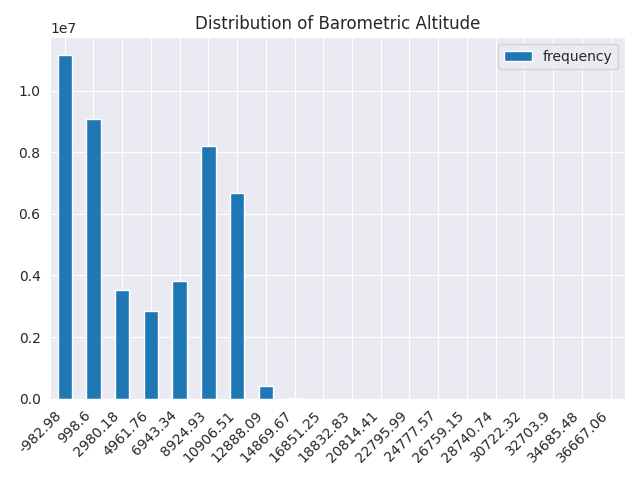

In [53]:
# Plot the histogram for barometric altitude
plt.figure(figsize=(12, 12))
baroaltitude_hist_df = pd.DataFrame(
    list(zip(*baroaltitude_hist)),
    columns=['bin', 'frequency']
)
baroaltitude_hist_df['bin'] = baroaltitude_hist_df['bin'].round(2)
baroaltitude_hist_df.set_index('bin').plot(kind='bar')
plt.xlabel(None)
plt.xticks(rotation=45, ha='right')
plt.title('Distribution of Barometric Altitude')
plt.tight_layout()
plt.show()
%matplot plt

**Observation:** We can see that `baroaltitude` is not normally distributed. The distribution is skewed to the right with high-value outliers. For sake of simplicity, we can impute the values by filling with previous non-null value given we are dealing with a time series dataset. 

**NOTE:** Imputing with forward fill is likely a limitation and should be addressed as a future consideration for improvement.

In [54]:
track_points_window = (
    Window.partitionBy('icao24')
    .orderBy('time')
    .rowsBetween(Window.unboundedPreceding, Window.currentRow)
)

track_points_df = track_points_df.withColumn('baroaltitude', F.last('baroaltitude', ignorenulls=True).over(track_points_window))

In [ ]:
# Get updated missing values report after imputing values
track_points_missing_values_report = get_missing_values(track_points_df)
track_points_missing_values_report.show(n=len(track_points_df.columns), truncate=False)

Execution Interrupted. Attempting to cancel the statement (statement_id=54)


#### Analyze Uniqueness

In [64]:
track_points_unique_counts = get_unique_values(track_points_df)
track_points_unique_counts.show(n=len(track_points_df.columns), vertical=True, truncate=False)

-RECORD 0------------------
 time           | 23612487 
 icao24         | 51535    
 lat            | 1351374  
 lon            | 8059576  
 velocity       | 89420    
 heading        | 685396   
 vertrate       | 802      
 callsign       | 78362    
 onground       | 2        
 alert          | 2        
 spi            | 2        
 squawk         | 4096     
 baroaltitude   | 2968     
 geoaltitude    | 5927     
 lastposupdate  | 42202030 
 lastcontact    | 43092460 
 serials        | 5316958  
 day_of_week    | 7        
 daynum_of_week | 7


In [12]:
# track_points_unique_counts.toPandas()

**(TODO) Observation:**

Low variance columns (categorical):
* List columns here

#### Encode Categorical Features
**NOTE**: Need to encode categorical string features with low variance and target only numeric features prior to identifying important/primary features

In [ ]:
track_points_categorical_features = [
    # TODO Create list of categorical features based on observations
]

encoded_features = [col + "_encoded" for col in track_points_categorical_features]

# Create a list of StringIndexer transformers
indexers = [StringIndexer(inputCol=col, outputCol=col + "_encoded") for col in track_points_categorical_features]

# Create a VectorAssembler to combine the indexed columns
assembler = VectorAssembler(inputCols=encoded_features, outputCol="features")

# Create a Pipeline to chain the transformers and assembler
pipeline = Pipeline(stages=indexers + [assembler])

# Fit and transform the DataFrame
indexer_model = pipeline.fit(track_points_df)
track_points_df_encoded = indexer_model.transform(track_points_df)

In [ ]:
track_points_df_encoded.select(*encoded_features).show(n=1, vertical=True, truncate=False)

In [ ]:
# Apply encoded changes
track_points_df = track_points_df_encoded

In [ ]:
# Drop features column that was used for indexer model
track_points_df = track_points_df.drop('features')

In [ ]:
track_points_df.show(n=1, vertical=True, truncate=False)

#### Identify Important/Primary Features

In [ ]:
track_points_df.dtypes

In [ ]:
numeric_cols = [c for c, t in track_points_df.dtypes if t in ('double', 'int', 'bigint', 'long', 'float')]
numeric_cols

In [ ]:
features = numeric_cols
target = 'eventscore'

# Create a VectorAssembler to combine features
assembler = VectorAssembler(inputCols=features, outputCol="rf_features", handleInvalid='skip')

# Create a RandomForestRegressor
rf = RandomForestRegressor(labelCol=target, featuresCol="rf_features", numTrees=100, maxBins=2000)

# Create a pipeline
pipeline = Pipeline(stages=[assembler, rf])

In [ ]:
# Split the data into training and testing sets
train_data, test_data = track_points_df.randomSplit([0.8, 0.2], seed=42)

In [ ]:
# Fit the random forest regressor model via pipeline (data cannot have any null values)
# TODO Need to analyze null data further and determine best approach for handling nulls (e.g., imputing null values or dropping rows with null values)
# NOTE: Setting handleInvalid='skip' for VectorAssembler will work around the null values issue
rf_model = pipeline.fit(train_data)

In [ ]:
# Make predictions on the test data
# predictions = rf_model.transform(test_data)

In [ ]:
# Evaluate the model
# evaluator = RegressionEvaluator(labelCol=target, predictionCol="prediction", metricName="rmse")
# rmse = evaluator.evaluate(predictions)
# print("Root Mean Squared Error (RMSE):", rmse)

In [ ]:
# Analyze feature importances
feature_importances = rf_model.stages[1].featureImportances
feature_importances

In [ ]:
# Map feature importances back to column names and build pandas dataframe, sorted by importance in descending order
feature_importance_dict = dict(zip(assembler.getInputCols(), feature_importances))
feature_importance_df = pd.DataFrame({'Feature': feature_importance_dict.keys(), 'Importance': feature_importance_dict.values()})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

In [ ]:
pd.set_option('display.max_rows', 100)
feature_importance_df.round(6)

In [ ]:
f, ax = plt.subplots(figsize=(16, 8))
ax = sns.barplot(data=feature_importance_df, x='Importance', y='Feature')
ax.set_title("Visualize feature scores of the features", weight='bold')
ax.set_xlabel("Feature importance score")
ax.set_ylabel("Features")
plt.tight_layout()
plt.show()
%matplot plt

#### Analyze Correlations for Primary Features

In [ ]:
# Assemble features into a vector column
numeric_track_points_df = track_points_df.select(*numeric_cols)
assembler = VectorAssembler(inputCols=numeric_track_points_df.columns, outputCol="numeric_features", handleInvalid='skip')
numeric_track_points_df = assembler.transform(numeric_track_points_df)

# Calculate correlation matrix
corr_matrix = Correlation.corr(numeric_track_points_df, "numeric_features").head()[0].toArray()

In [ ]:
# Convert to pandas dataframe for plotting
corr_df = pd.DataFrame(corr_matrix, columns=numeric_track_points_df.columns[:-1], index=numeric_track_points_df.columns[:-1])

In [ ]:
corr_df

In [ ]:
# Plot heatmap
# See https://repost.aws/questions/QULOKRL66TSWy-WY4F9kL25w/how-to-get-glue-interactive-session-notebook-to-show-matplotlib-plot
plt.clf() # Clear current figure
fig = plt.figure(figsize=(32, 16))
sns.heatmap(corr_df, annot=True, fmt='.1f', annot_kws={"fontsize": 5}, cmap="coolwarm")
plt.title('Northern California TRACON Correlation Matrix')
plt.tight_layout()
# plt.savefig('./track_points_numeric_features_correlation_matrix.png') # NOTE: savefig does not work in glue pyspark. Need to shift+right click on the image and save manually
plt.show()
%matplot plt

In [ ]:
corr_df.to_csv('s3://endurasoft-dev-risk-framework/analysis/uas_risk_analysis_eda/track_points_numeric_features_correlation_matrix.csv', index=False)

In [ ]:
# Reduce number of features and select only features of interest
features_of_interest = [
    # TODO Create list representing features of interest
]

corr_df_foi = corr_df.loc[features_of_interest, :][features_of_interest]

# Plot heatmap
# See https://repost.aws/questions/QULOKRL66TSWy-WY4F9kL25w/how-to-get-glue-interactive-session-notebook-to-show-matplotlib-plot
plt.clf() # Clear current figure
fig = plt.figure(figsize=(30, 12))
sns.heatmap(corr_df_foi, annot=True, fmt='.1f', annot_kws={"fontsize": 12}, cmap="coolwarm")
plt.xticks(rotation=70)
plt.title('OpenSky Network Track Points Correlation Matrix (Features of Interest)', weight='bold')
plt.tight_layout()
plt.show()
%matplot plt

#### Analyze Covariance
Covariance measures the influence of change between features.

In [ ]:
numeric_track_points_df.columns

In [ ]:
vector_col = "cov_features"
assembler = VectorAssembler(inputCols=numeric_track_points_df.columns[:-1], outputCol=vector_col, handleInvalid="skip")
df_vector = assembler.transform(numeric_track_points_df).select(vector_col)

In [ ]:
# Must have single vector dtype
df_vector.dtypes

In [ ]:
row_matrix = RowMatrix(df_vector.rdd.map(list))
cov_matrix = row_matrix.computeCovariance()

In [ ]:
# Convert to pandas dataframe for plotting
cov_df = pd.DataFrame(cov_matrix.toArray(), columns=numeric_track_points_df.columns[:-1], index=numeric_track_points_df.columns[:-1])

In [ ]:
cov_df

In [ ]:
# Plot heatmap
# See https://repost.aws/questions/QULOKRL66TSWy-WY4F9kL25w/how-to-get-glue-interactive-session-notebook-to-show-matplotlib-plot
plt.clf() # Clear current figure
fig = plt.figure(figsize=(32, 16))
sns.heatmap(cov_df, annot=True, fmt='.1g', annot_kws={"fontsize": 5}, cmap="coolwarm")
plt.title('OpenSky Network Track Points Covariance Matrix')
plt.tight_layout()
plt.show()
%matplot plt

In [ ]:
cov_df_foi = cov_df.loc[features_of_interest, :][features_of_interest]

# Plot heatmap
# See https://repost.aws/questions/QULOKRL66TSWy-WY4F9kL25w/how-to-get-glue-interactive-session-notebook-to-show-matplotlib-plot
plt.clf() # Clear current figure
fig = plt.figure(figsize=(30, 12))
sns.heatmap(cov_df_foi, annot=True, fmt='.1g', annot_kws={"fontsize": 12}, cmap="coolwarm")
plt.xticks(rotation=70)
plt.title('OpenSky Network Track Points Covariance Matrix (Features of Interest)', weight='bold')
plt.tight_layout()
plt.show()
%matplot plt

* **Positive covariance**: The two variables tend to move in the same direction. 
* **Negative covariance**: The two variables tend to move in opposite directions. 
* **Zero covariance**: The two elements do not vary together.

#### Analyze Events by Altitude Bins

In [65]:
alt_bins = [0, 150, 200, 250, 500, 750, 1000, 2500, 5000, 10000, float("inf")]
alt_labels = ['<150', '150-200', '200-250', '250-500', '500-750', '750-1000', '1000-2500', '2500-5000', '5000-10000', '>10000']

In [66]:
# Create the altitude bins for baroaltitude
track_points_df = track_points_df.withColumn("altitude_bin", 
                   F.when(F.col("baroaltitude") < alt_bins[1], alt_labels[0])
                   .when((F.col("baroaltitude") >= alt_bins[1]) & (F.col("baroaltitude") < alt_bins[2]), alt_labels[1])
                   .when((F.col("baroaltitude") >= alt_bins[2]) & (F.col("baroaltitude") < alt_bins[3]), alt_labels[2])
                   .when((F.col("baroaltitude") >= alt_bins[3]) & (F.col("baroaltitude") < alt_bins[4]), alt_labels[3])
                   .when((F.col("baroaltitude") >= alt_bins[4]) & (F.col("baroaltitude") < alt_bins[5]), alt_labels[4])
                   .when((F.col("baroaltitude") >= alt_bins[5]) & (F.col("baroaltitude") < alt_bins[6]), alt_labels[5])
                   .when((F.col("baroaltitude") >= alt_bins[6]) & (F.col("baroaltitude") < alt_bins[7]), alt_labels[6])
                   .when((F.col("baroaltitude") >= alt_bins[7]) & (F.col("baroaltitude") < alt_bins[8]), alt_labels[7])
                   .when((F.col("baroaltitude") >= alt_bins[8]) & (F.col("baroaltitude") < alt_bins[9]), alt_labels[8])
                   .otherwise(alt_labels[9]))

In [67]:
# Analyze event score by altitude_bin
print('='*100)
print(f'OpenSky Network Track Points by Altitude Bin')
print('='*100)
track_points_df.groupBy('altitude_bin').agg(
    F.count('*').alias('track_points_count'),
).orderBy(F.col('track_points_count').desc()).show()

OpenSky Network Track Points by Altitude Bin
+------------+------------------+
|altitude_bin|track_points_count|
+------------+------------------+
|      >10000|          16764454|
|  5000-10000|           9392830|
|   1000-2500|           7934471|
|   2500-5000|           4718559|
|     250-500|           3160821|
|     500-750|           2873693|
|    750-1000|           2631313|
|        <150|           1395922|
|     200-250|            579841|
|     150-200|            546516|
+------------+------------------+


## Data Fusion
Use geospatial analysis to identify which UASFM grids the track points and uas sightings overlap and assign a unique grid ID accordingly to each record. The goal it to end up with a single cohesive dataset representing a join between track points, uas sightings, and UASFM grids, where each record has a UASFM global id associated with it.

In [ ]:
# TODO Create combined dataframe as join between track points, uas sightings, and uasfm grids
combined_df = None

### Aggregate Analysis
Analyze fused dataset for near mid-air collision (NMAC) and mid-air collision (MAC) risk for UAS.

In [ ]:
# Clean column names
combined_df = clean_column_names(combined_df)

In [ ]:
# Convert boolean columns to integer
bool_cols = [col_name for col_name, col_type in combined_df.dtypes if col_type == "boolean"]

# Convert boolean columns to integers
for col_name in bool_cols:
    combined_df = combined_df.withColumn(col_name, F.col(col_name).cast(T.IntegerType()))

In [ ]:
combined_df.persist()

#### Analyze Events by Facility

In [ ]:
combined_df.groupBy('facility').count().show()

In [ ]:
# Average event score by facility
combined_df.groupBy('facility').agg(
    F.count('eventscore').alias('event_count'),
    F.min('eventscore').alias('min_eventscore'),
    F.max('eventscore').alias('max_eventscore'),
    F.avg('eventscore').alias('average_eventscore'),
    F.stddev('eventscore').alias('stddev_eventscore'),
).show()

#### Analyze Events by Geolocation

##### Clustered Heatmap (Folium)

In [ ]:
cell_size = 0.007

df_grid = combined_df.withColumn("grid_lat", F.floor(combined_df["latitude"] / cell_size) * cell_size) \
             .withColumn("grid_lon", F.floor(combined_df["longitude"] / cell_size) * cell_size) \
             .groupBy("grid_lat", "grid_lon") \
             .agg(F.count("*").alias("point_count"))

In [ ]:
df_grid_pandas = df_grid.toPandas()

In [ ]:
df_grid_pandas

In [ ]:
map_center = [df_grid_pandas["grid_lat"].mean(), df_grid_pandas["grid_lon"].mean()]
m = folium.Map(location=map_center, zoom_start=10)

# Create the heatmap layer
HeatMap(
    data=df_grid_pandas[["grid_lat", "grid_lon", "point_count"]].values.tolist(),
    radius=15, 
    blur=10
).add_to(m)
m

In [ ]:
# s3://gdit-faa-datachallenge-proto/notebooks/aria_airborne_pyspark_eda/
map_filename = 'aria_airborne_events_geolocation.html'
buf = io.BytesIO(m._repr_html_().encode('utf-8'))
s3_client.put_object(Bucket='gdit-faa-datachallenge-proto', Key=f'notebooks/aria_airborne_pyspark_eda/{map_filename}', Body=buf)
buf.close()

##### Shader-based Point Density Heatmap (Plotly)

In [ ]:
# Apply moving average to reduce density of track points
# uniqueid
# latitude
# longitude
# ateventtime_timestamp - 2022-05-13T17:36:42.971Z         

In [ ]:
# ateventtime_timestamp - 2022-05-13T17:36:42.971Z -> format string: "yyyy-MM-dd'T'HH:mm:ss.SSS'Z'" (can be inferred by pyspark)
combined_df = combined_df.withColumn('ateventtime_timestamp', F.to_timestamp('ateventtime_timestamp'))

In [ ]:
combined_df.select('ateventtime_timestamp').dtypes

In [ ]:
# Define the window specification
# window_spec = Window.partitionBy("uniqueid").orderBy("ateventtime_timestamp").rowsBetween(-1, 1)

# # Calculate the moving average for latitude and longitude
# windowed_df = combined_df.withColumn("avg_latitude", F.avg("latitude").over(window_spec))
# windowed_df = windowed_df.withColumn("avg_longitude", F.avg("longitude").over(window_spec))

# # Select the desired columns (including the moving averages)
# windowed_df = windowed_df.select("uniqueid", "ateventtime_timestamp", "avg_latitude", "avg_longitude")

# # Drop duplicates (optional, to further reduce density)
# mav_df = windowed_df.dropDuplicates(["uniqueid", "avg_latitude", "avg_longitude"])

# mav_df.show(n=1, vertical=True, truncate=False)

In [ ]:
# Determine average time diff in seconds between events; this will help determine reduction ratio
# Calculate the time difference between consecutive records
window = Window.orderBy(F.col("ateventtime_timestamp"))
combined_df = combined_df.withColumn("prev_timestamp", F.lag("ateventtime_timestamp").over(window))
combined_df = combined_df.withColumn("time_diff", F.unix_timestamp("ateventtime_timestamp") - F.unix_timestamp("prev_timestamp"))

# Calculate the average time difference in seconds
avg_time_diff = combined_df.agg(F.avg("time_diff")).collect()[0][0]

print("Average time difference in seconds:", avg_time_diff)

In [ ]:
# Create year, month, day, hour, minute, seconds columns
combined_df = combined_df.withColumn("year", F.year("ateventtime_timestamp")) \
                         .withColumn("month", F.month("ateventtime_timestamp")) \
                         .withColumn("day", F.dayofmonth("ateventtime_timestamp")) \
                         .withColumn("hour", F.hour("ateventtime_timestamp")) \
                         .withColumn("minute", F.minute("ateventtime_timestamp")) \
                         .withColumn("second", F.second("ateventtime_timestamp"))

In [ ]:
# Apply date range based windowing based on https://stackoverflow.com/a/45824339
# NOTE: This will take a while to run depending on the size of the dataset
# Function to calculate number of seconds from number of days
days_to_seconds = lambda i: i * 86400

# Create window by casting timestamp to long (number of seconds)
# https://spark.apache.org/docs/latest/api/python/reference/pyspark.sql/api/pyspark.sql.Window.rangeBetween.html
# https://spark.apache.org/docs/latest/api/python/reference/pyspark.sql/api/pyspark.sql.Window.rowsBetween.html
window_spec = Window.partitionBy("uniqueid").orderBy(F.col("ateventtime_timestamp").cast('long')).rangeBetween(-days_to_seconds(1), 0)
# window_spec = Window.orderBy(F.col('ateventtime_timestamp')).rowsBetween(-1, 0)
# window_spec = Window.partitionBy("facility").orderBy(F.col("ateventtime_timestamp")).rowsBetween(Window.currentRow, 1)

# Calculate the moving average for latitude and longitude
windowed_df = combined_df.withColumn("avg_latitude", F.avg("latitude").over(window_spec))
windowed_df = windowed_df.withColumn("avg_longitude", F.avg("longitude").over(window_spec))

# Calculate the moving average for event score
# windowed_df = combined_df.withColumn("avg_eventscore", F.avg("eventscore").over(window_spec))

# Drop duplicates to further reduce density
mav_df = windowed_df.dropDuplicates(["uniqueid", "avg_latitude", "avg_longitude"])
# mav_df = windowed_df.dropDuplicates(["avg_eventscore"])
# mav_df.show(n=1, vertical=True, truncate=False)

In [ ]:
# Analyze density reduction with moving average
# total starting records = 3,590,562
#   reduced to 3,039,839 with rowsBetween(-2, 0)
#   reduced to 2,897,022 with rowsBetween(-1, 0)
#   reduced to 2,396,445 with rowsBetween(Window.currentRow, 1)
f'{combined_df.count():,}', f'{mav_df.count():,}'

In [ ]:
reduced_df = combined_df.withColumn('trunc_timestamp', F.date_trunc('second', F.col('ateventtime_timestamp')))\
                        .groupBy('trunc_timestamp')\
                        .agg(*[F.first(col).alias(col) for col in combined_df.columns])\
                        .select(*combined_df.columns)\
                        .orderBy(F.col('ateventtime_timestamp').asc())

In [ ]:
# Analyze density reduction with date truncation
f'{combined_df.count():,}', f'{reduced_df.count():,}'

In [ ]:
sampled_df = combined_df.sample(fraction=0.1, seed=42)

In [ ]:
# Analyze density reduction with sampling
f'{combined_df.count():,}', f'{sampled_df.count():,}'

In [ ]:
sampled_df_pandas = sampled_df.toPandas()

In [ ]:
# Plot Latitude & Longitude on a map using plotly and datashader - https://plotly.com/python/datashader/
cvs = ds.Canvas(plot_width=1000, plot_height=1000)
agg = cvs.points(sampled_df_pandas, x='longitude', y='latitude')
coords_lat, coords_lon = agg.coords['latitude'].values, agg.coords['longitude'].values

# Corners of the image, which need to be passed to mapbox
coordinates = [[coords_lon[0], coords_lat[0]],
               [coords_lon[-1], coords_lat[0]],
               [coords_lon[-1], coords_lat[-1]],
               [coords_lon[0], coords_lat[-1]]]

img = tf.shade(agg, cmap=fire)[::-1].to_pil()

# Trick to create rapidly a figure with mapbox axes
fig = px.scatter_mapbox(
    sampled_df_pandas[:1], # First row, all columns
    lat='latitude', 
    lon='longitude',
    opacity=0.0, # Hidden
    zoom=10,
    height=600,
    width=1600,
    center={'lat': 36.778259, 'lon': -119.417931}, # California
)

# Add the datashader image as a mapbox layer image
fig.update_layout(
    mapbox_style="carto-darkmatter",
    mapbox_layers = [
        {
            "sourcetype": "image",
            "source": img,
            "coordinates": coordinates
        }
    ],
    margin=dict(l = 0, r = 0, t = 0, b = 0),
)
fig.show()

In [ ]:
# Save the plotly heatmap
string_buf = io.StringIO()
fig.write_html(string_buf)
string_buf.seek(0)

string_data = string_buf.getvalue()
bytes_buf = io.BytesIO(string_data.encode('utf-8'))

# s3://gdit-faa-datachallenge-proto/notebooks/aria_airborne_pyspark_eda/
fig_filename = 'aria_airborne_events_plotly_heatmap_shader.html'
s3_client.put_object(Bucket='gdit-faa-datachallenge-proto', Key=f'notebooks/aria_airborne_pyspark_eda/{fig_filename}', Body=bytes_buf)
bytes_buf.close()
string_buf.close()

#### KMeans Clustering by Location

In [ ]:
combined_df = combined_df.drop('location_features')

In [ ]:
# TODO determine the optimal number of clusters (k)
k = 10 
kmeans = KMeans(k=k, featuresCol="location_features")

# Assemble features into a vector
assembler = VectorAssembler(inputCols=["latitude", "longitude"], outputCol="location_features")
combined_df = assembler.transform(combined_df)

# Train the model
kmeans_model = kmeans.fit(combined_df)

# Assign cluster labels to each track point
combined_df = kmeans_model.transform(combined_df)

In [ ]:
combined_df.show(n=1, vertical=True, truncate=True)

In [ ]:
combined_df.groupBy('prediction').count().show()

## Clean up Resources

In [57]:
%stop_session

Stopping session: b0b343e7-c02e-4450-8f23-2f023e63536f
Stopped session.
